In [54]:
import pandas as pd

df = pd.read_csv('./data/apple_quality.csv')
df

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good
...,...,...,...,...,...,...,...,...,...
3996,3996.0,-0.293118,1.949253,-0.204020,-0.640196,0.024523,-1.087900,1.854235285,good
3997,3997.0,-2.634515,-2.138247,-2.440461,0.657223,2.199709,4.763859,-1.334611391,bad
3998,3998.0,-4.008004,-1.779337,2.366397,-0.200329,2.161435,0.214488,-2.229719806,good
3999,3999.0,0.278540,-1.715505,0.121217,-1.154075,1.266677,-0.776571,1.599796456,good


In [5]:
df.isnull().sum()
df = df.dropna()
df

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good
...,...,...,...,...,...,...,...,...,...
3995,3995.0,0.059386,-1.067408,-3.714549,0.473052,1.697986,2.244055,0.137784369,bad
3996,3996.0,-0.293118,1.949253,-0.204020,-0.640196,0.024523,-1.087900,1.854235285,good
3997,3997.0,-2.634515,-2.138247,-2.440461,0.657223,2.199709,4.763859,-1.334611391,bad
3998,3998.0,-4.008004,-1.779337,2.366397,-0.200329,2.161435,0.214488,-2.229719806,good


In [8]:
def quality_function(x):
    if x == "good":
        return 1
    else:
        return 0

df["Quality"].unique()
df["quality_num"] = df["Quality"].apply(quality_function)

In [9]:
df 

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality,quality_num
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good,1
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good,1
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad,0
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good,1
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good,1
...,...,...,...,...,...,...,...,...,...,...
3995,3995.0,0.059386,-1.067408,-3.714549,0.473052,1.697986,2.244055,0.137784369,bad,0
3996,3996.0,-0.293118,1.949253,-0.204020,-0.640196,0.024523,-1.087900,1.854235285,good,1
3997,3997.0,-2.634515,-2.138247,-2.440461,0.657223,2.199709,4.763859,-1.334611391,bad,0
3998,3998.0,-4.008004,-1.779337,2.366397,-0.200329,2.161435,0.214488,-2.229719806,good,1


Accuracy: 67.00%


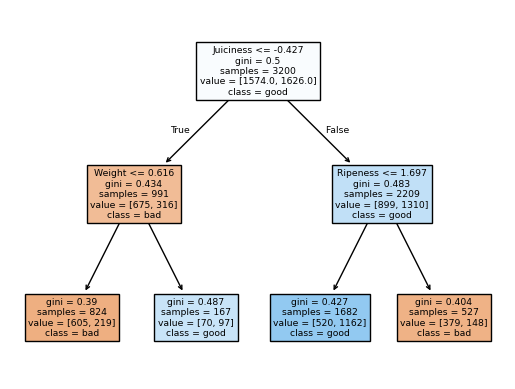

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df.drop(columns=["Quality", "quality_num"])
y = df["quality_num"]

X_train, X_validate, y_train, y_validate = train_test_split(X, y, test_size=0.2, random_state=0)

clf = DecisionTreeClassifier(random_state=0, max_depth=2)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_validate)
accuracy = accuracy_score(y_validate, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
_ = plot_tree(clf, feature_names=X.columns, filled=True, class_names=["bad", "good"])

In [53]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
X = df.drop(columns=["Quality", "quality_num"])
y = df["quality_num"]

X_train, X_validate, y_train, y_validate = train_test_split(X, y, test_size=0.2, random_state=i)

prediction_collected = np.zeros(len(y_validate))
scores = []
N = 1000
for i in range(N):
    clf = DecisionTreeClassifier()
    X_bag, _, y_bag, _ = train_test_split(X_train, y_train, test_size=0.2, random_state=i)
    clf.fit(X_bag, y_bag)
    y_pred = clf.predict(X_validate)
    prediction_collected += y_pred
    accuracy = accuracy_score(y_validate, y_pred)
    scores.append(accuracy)

prediction = prediction_collected / N
accuracy = accuracy_score(y_validate, np.round(prediction))
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 87.12%


(array([3., 0., 1., 0., 3., 3., 2., 4., 3., 1.]),
 array([0.8375  , 0.839375, 0.84125 , 0.843125, 0.845   , 0.846875,
        0.84875 , 0.850625, 0.8525  , 0.854375, 0.85625 ]),
 <BarContainer object of 10 artists>)

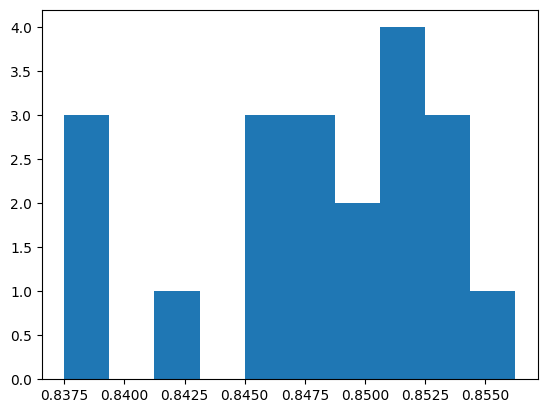

In [65]:
from sklearn.ensemble import RandomForestClassifier

X_train, X_validate, y_train, y_validate = train_test_split(X, y, test_size=0.2, random_state=4
                                                            )
accuracies = []
for i in range(20):
    rf_clf = RandomForestClassifier(n_estimators=100, random_state=i)
    rf_clf.fit(X_train, y_train)
    y_pred = rf_clf.predict(X_validate)
    accuracy = accuracy_score(y_validate, y_pred)
    accuracies.append(accuracy)
    #print(f"Accuracy: {accuracy*100:.2f}%")
import matplotlib.pyplot as plt
plt.hist(accuracies)

['A_id', 'Size', 'Weight', 'Sweetness', 'Crunchiness', 'Juiciness', 'Ripeness']


<Figure size 1000x1200 with 0 Axes>

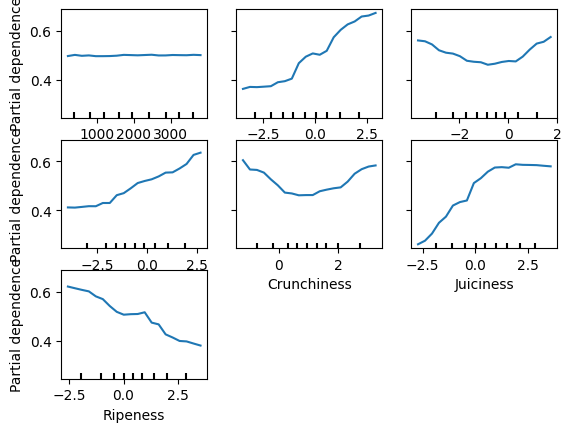

In [69]:
from sklearn.inspection import PartialDependenceDisplay

features = X.select_dtypes(include=[np.number]).columns.tolist()
print(features)
plt.figure(figsize=(10, 12))
PartialDependenceDisplay.from_estimator(rf_clf, X_validate, features=features, grid_resolution=20)
